# Лабораторная работа 2
## Временные ряды: прогноз температуры на 1 неделю вперёд

## Импорты

In [116]:
from openpyxl import load_workbook
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (r2_score, mean_absolute_error,
                             mean_absolute_percentage_error,
                             mean_squared_error, root_mean_squared_error,
                             median_absolute_error)
from xgboost import XGBRegressor
from mpl_toolkits.axes_grid1 import make_axes_locatable
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

## 1. Все листы Excel
В файле 8 листов, но реальные данные только в трёх (два скрыты). Имена листов записаны в cp1251, прочитанной как latin1 — починим.

In [117]:
file = 'have_fun.xlsx'

def fix_encoding(s):
    # cp1251, ошибочно прочитанный как latin1
    if isinstance(s, str):
        try:
            return s.encode('latin1').decode('cp1251')
        except Exception:
            return s
    return s

wb = load_workbook(file, data_only=True)
for ws in wb.worksheets:
    print(f'{fix_encoding(ws.title):40s}  state={ws.sheet_state}  dim={ws.dimensions}')

Лист1                                     state=visible  dim=A1:J125125
Лист1                                     state=visible  dim=A1:A1
МАИ                                       state=visible  dim=A1:A1
это                                       state=visible  dim=A1:A1
я                                         state=visible  dim=A1:A1
!                                         state=visible  dim=A1:A1
Лист2_строковые_NaN_выбросы               state=hidden  dim=A1:Y125170
Лист3_смешанные_типы                      state=hidden  dim=A1:J122737


In [118]:
# Читаем все листы, оставляем только те где есть колонка 'ds'
raw = pd.read_excel(file, sheet_name=None, engine='openpyxl')

sheets = {}
for name, d in raw.items():
    d = d.copy()
    d.columns = [fix_encoding(col) for col in d.columns]
    d = d.map(fix_encoding)

    if 'ds' in d.columns and len(d) > 10:
        sheets[fix_encoding(name)] = d

for n, d in sheets.items():
    print(n, '->', d.shape)

Лист1 -> (125124, 10)
Лист2_строковые_NaN_выбросы -> (125169, 25)
Лист3_смешанные_типы -> (122736, 10)


In [119]:
# Что внутри каждого листа
for n, d in sheets.items():
    print('=' * 60, n)
    print(d.dtypes)
    print('пропусков:', d.isna().sum().sum())
    display(d.head())

============================================================ Лист1
temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
rain                           float64
snowfall                       float64
weathercode                      int64
wind_speed_10m                 float64
surface_pressure               float64
ds                      datetime64[us]
city                               str
dtype: object
пропусков: 4374


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.800000,82,0.0,0.0,0.0,3,19.100000,1010.000000,2020-01-31 02:00:00,Геленджик
1,-3.000000,70,0.0,0.0,0.0,3,24.000000,981.900024,2025-02-28 09:00:00,Благовещенск
2,-1.300000,86,0.0,0.0,0.0,2,8.800000,1021.200012,2022-01-03 02:00:00,Геленджик
3,19.299999,49,0.0,0.0,0.0,0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик
4,9.600000,89,0.0,0.0,0.0,0,8.800000,1024.400024,2025-04-16 05:00:00,Геленджик


============================================================ Лист2_строковые_NaN_выбросы
temperature_2m                  object
relative_humidity_2m           float64
precipitation                   object
rain                           float64
snowfall                       float64
weathercode                    float64
wind_speed_10m                  object
surface_pressure               float64
ds                      datetime64[us]
city                               str
Unnamed: 10                    float64
Unnamed: 11                        str
Unnamed: 12                        str
Unnamed: 13                        str
Unnamed: 14                     object
Unnamed: 15                     object
Unnamed: 16                     object
Unnamed: 17                     object
Unnamed: 18                     object
Unnamed: 19                     object
Unnamed: 20                     object
Unnamed: 21                     object
Unnamed: 22                     object
Unnamed: 23   

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,-6.5,92.0,0,0.0,0.0,3.0,10.8,1000.500000,2019-01-01 00:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-6.8,92.0,0,0.0,0.0,3.0,10.5,1000.299988,2019-01-01 01:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-6.8,92.0,0,0.0,0.0,3.0,10.8,1000.000000,2019-01-01 02:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-5.8,93.0,0,0.0,0.0,3.0,12.2,999.299988,2019-01-01 03:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,79.276929,93.0,0,0.0,0.0,3.0,14.4,998.599976,2019-01-01 04:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


============================================================ Лист3_смешанные_типы
temperature_2m                  object
relative_humidity_2m           float64
precipitation                   object
rain                           float64
snowfall                       float64
weathercode                     object
wind_speed_10m                  object
surface_pressure               float64
ds                      datetime64[us]
city                               str
dtype: object
пропусков: 259


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-1.8,85.0,0,0.0,0.00,3,23.5,1015.200012,2019-01-01 00:00:00,Санкт-Петербург
1,-1.9,83.0,0,0.0,0.00,3,26,1013.200012,2019-01-01 01:00:00,Санкт-Петербург
2,-2,85.0,0,0.0,0.00,3,26.200001,1011.700012,2019-01-01 02:00:00,Санкт-Петербург
3,-2.3,86.0,0,0.0,0.00,3,26.9,1009.900024,2019-01-01 03:00:00,Санкт-Петербург
4,-2.3,86.0,0.2,0.0,0.14,71,27.9,1007.700012,2019-01-01 04:00:00,Санкт-Петербург


## 2. Очистка и объединение

In [120]:
# Сшиваем все листы в один датафрейм
df = pd.concat(list(sheets.values()), ignore_index=True)

# Выкидываем мусорные пустые столбцы Unnamed: *
df = df.drop(columns=[c for c in df.columns if str(c).startswith('Unnamed')])
df = df.dropna(how='all').dropna(axis=1, how='all')

print('размер:', df.shape)
df.info()

размер: (370575, 10)
<class 'pandas.DataFrame'>
Index: 370575 entries, 0 to 373028
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        368016 non-null  object        
 1   relative_humidity_2m  370570 non-null  float64       
 2   precipitation         368392 non-null  object        
 3   rain                  370545 non-null  float64       
 4   snowfall              370545 non-null  float64       
 5   weathercode           370544 non-null  object        
 6   wind_speed_10m        368943 non-null  object        
 7   surface_pressure      370544 non-null  float64       
 8   ds                    370543 non-null  datetime64[us]
 9   city                  370542 non-null  str           
dtypes: datetime64[us](1), float64(4), object(4), str(1)
memory usage: 31.1+ MB


### Найдём странные значения в числовых столбцах
Сначала смотрим, что вообще встречается, и только потом решаем что с этим делать.

In [121]:
num_cols = [c for c in df.columns if c not in ['ds', 'city']]
found = {}

for col in num_cols:
    strange = set(v for v in df[col] if isinstance(v, str))
    if strange:
        found[col] = strange
        print(col, '->', strange)

temperature_2m -> {'NAN', 'холодно', 'нормально', '?', 'нет данных', '---', 'жарко'}
precipitation -> {'NAN', '---', 'сухо', '?', 'ливень', 'нет данных', 'морось'}
weathercode -> {'пасмурно', 'дождь', 'солнечно', 'снег'}
wind_speed_10m -> {'NAN', 'шторм', 'гроза', 'ветрено', 'тихо', 'туман', '?', 'нет данных', '---'}


На основе того что нашли, собираем словари замен. Где у слова есть осмысленное число — заменяем числом. Всё остальное из `found`, что не попало в словари — автоматически считаем мусором и отправляем в `NaN` (так список мусора не из головы, а из реальных значений в таблице).

In [122]:
temp_map    = {'холодно': 0, 'нормально': 15, 'жарко': 30}
wind_map    = {'тихо': 0, 'ветрено': 7, 'шторм': 20, 'гроза': 15, 'туман': 2}
precip_map  = {'сухо': 0, 'морось': 0.5, 'ливень': 10}
weather_map = {'солнечно': 0, 'пасмурно': 3, 'дождь': 61, 'снег': 71}  # коды WMO

if 'num_cols' not in globals():
    num_cols = [c for c in df.columns if c not in ['ds', 'city']]

if 'found' not in globals():
    found = {}
    for col in num_cols:
        strange = set(v for v in df[col] if isinstance(v, str))
        if strange:
            found[col] = strange
            print(col, '->', strange)

# Что мы считаем 'значением' — известные слова. Всё прочее, что нашлось в found — мусор.
known = set(temp_map) | set(wind_map) | set(precip_map) | set(weather_map)
garbage = set()
for col, values in found.items():
    garbage |= (values - known)
print('Мусор:', garbage)

df['temperature_2m'] = df['temperature_2m'].replace(temp_map)
df['wind_speed_10m'] = df['wind_speed_10m'].replace(wind_map)
df['precipitation']  = df['precipitation'].replace(precip_map)
df['weathercode']    = df['weathercode'].replace(weather_map)

for col in num_cols:
    if df[col].dtype == object:
        df[col] = pd.to_numeric(df[col].replace(list(garbage), np.nan), errors='coerce')

df['ds'] = pd.to_datetime(df['ds'], errors='coerce').dt.floor('h')
df.info()

Мусор: {'NAN', '?', 'нет данных', '---'}
<class 'pandas.DataFrame'>
Index: 370575 entries, 0 to 373028
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        367004 non-null  float64       
 1   relative_humidity_2m  370570 non-null  float64       
 2   precipitation         367600 non-null  float64       
 3   rain                  370545 non-null  float64       
 4   snowfall              370545 non-null  float64       
 5   weathercode           370544 non-null  float64       
 6   wind_speed_10m        368683 non-null  float64       
 7   surface_pressure      370544 non-null  float64       
 8   ds                    370543 non-null  datetime64[us]
 9   city                  370542 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 31.1 MB


### Чистим города
По словарю исправлений из обоих референсов.

In [123]:
df['city'] = df['city'].astype(str).str.strip().str.capitalize()
print('до:', sorted(df['city'].dropna().unique()))

city_fix = {
    'Москва':          ['Москва', 'Мосва'],
    'Санкт-Петербург': ['Санкт-петербург'],
    'Сочи':            ['Сочи', 'Сычи', 'Счи', 'Соч'],
    'Находка':         ['Находка'],
    'Благовещенск':    ['Благовещенск', 'Благовещенскк', 'Благовещенс'],
    'Геленджик':       ['Геленджик', 'Геленджикк', 'Геленджи'],
}

def to_normal(name):
    for good, bad in city_fix.items():
        if name in bad:
            return good
    return np.nan

df['city'] = df['city'].apply(to_normal)
print('после:', sorted(df['city'].dropna().unique()))
print('пропусков в city:', df['city'].isna().sum())

до: ['Благовещенс', 'Благовещенск', 'Благовещенскк', 'Геленджи', 'Геленджик', 'Геленджикк', 'Мосва', 'Москва', 'Находка', 'Санкт-петербург', 'Соч', 'Сочи', 'Счи', 'Сычи']
после: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
пропусков в city: 33


In [124]:
# Выкидываем строки без города/даты и дубликаты
df = df.dropna(subset=['city', 'ds']).drop_duplicates()
print('размер:', df.shape)

размер: (368090, 10)


### Часовая сетка и заполнение пропусков

In [125]:
# Если на одну (ds, city) попало несколько строк — усредним
df = df.groupby(['ds', 'city'], as_index=False).mean(numeric_only=True)

# Делаем сплошную часовую сетку для каждого города
parts = []
for city, sub in df.groupby('city'):
    sub = sub.set_index('ds').sort_index()
    idx = pd.date_range(sub.index.min(), sub.index.max(), freq='h')
    sub = sub.reindex(idx)
    sub['city'] = city
    sub.index.name = 'ds'
    parts.append(sub.reset_index())
df = pd.concat(parts, ignore_index=True)

print('пропусков до интерполяции:')
print(df.isna().sum())

пропусков до интерполяции:
ds                         0
city                       0
temperature_2m          3633
relative_humidity_2m     102
precipitation           3050
rain                      97
snowfall                  97
weathercode               97
wind_speed_10m          1934
surface_pressure          97
dtype: int64


### Выбросы
Если резать только по IQR — обнулятся осадки (там много нулей и редкие большие значения). Поэтому сначала ставим разумные физические границы, потом интерполируем, потом IQR для температуры.

In [126]:
bounds = {
    'temperature_2m':       (-50, 50),
    'relative_humidity_2m': (0, 100),
    'precipitation':        (0, 50),
    'rain':                 (0, 50),
    'snowfall':             (0, 20),
    'wind_speed_10m':       (0, 60),
    'surface_pressure':     (950, 1050),
}

for col, (lo, hi) in bounds.items():
    if col in df.columns:
        df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan

# Интерполяция внутри каждого города
filled = []
for city, sub in df.groupby('city'):
    sub = sub.sort_values('ds').copy()
    sub[num_cols] = sub[num_cols].interpolate(method='linear', limit_direction='both').ffill().bfill()
    filled.append(sub)
df = pd.concat(filled, ignore_index=True)

# Доп. обрезка температуры по IQR (k=3, чтобы зиму/лето не зарезать)
for city in df['city'].unique():
    mask = df['city'] == city
    q1, q3 = df.loc[mask, 'temperature_2m'].quantile([0.25, 0.75])
    iqr = q3 - q1
    df.loc[mask, 'temperature_2m'] = df.loc[mask, 'temperature_2m'].clip(q1 - 3*iqr, q3 + 3*iqr)

df.groupby('city')['temperature_2m'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Благовещенск,61368.0,2.21,15.98,-41.90,-11.7,3.5,16.3,35.0
Геленджик,61368.0,14.36,8.53,-10.00,8.1,13.8,21.2,37.8
Москва,61368.0,6.60,11.07,-49.90,-1.0,6.4,15.3,34.8
Находка,61347.0,6.77,12.02,-49.99,-2.5,7.8,17.0,33.2
Санкт-Петербург,61368.0,6.84,9.66,-28.80,0.1,5.9,14.7,35.7
Сочи,61368.0,15.04,7.51,-11.20,9.1,14.7,21.4,35.3


## 3. Анализ временного ряда

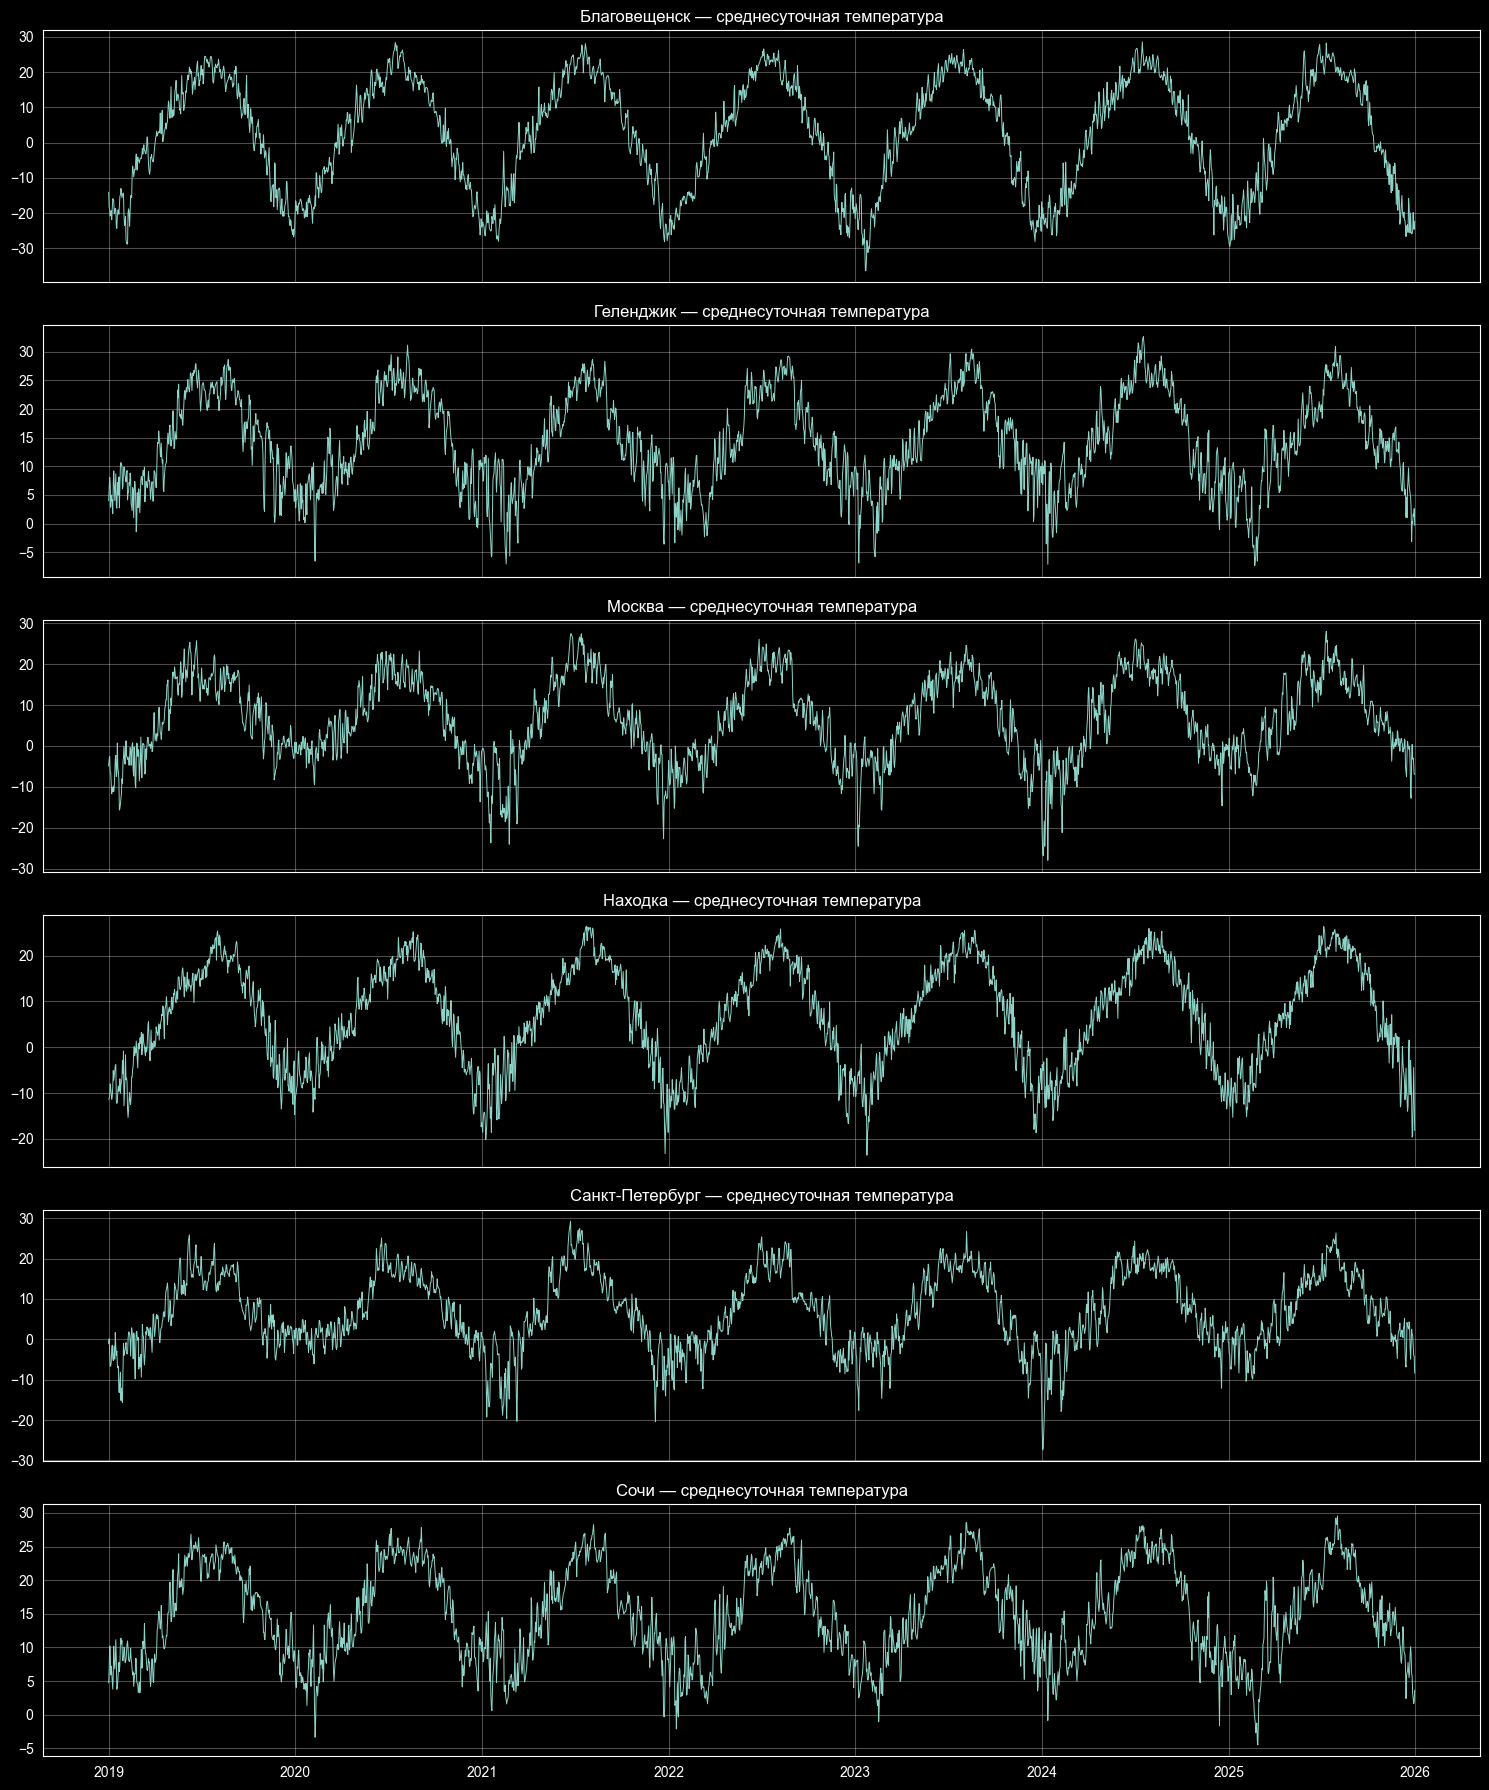

In [127]:
cities = sorted(df['city'].dropna().unique())
fig, axes = plt.subplots(len(cities), 1, figsize=(15, 3*len(cities)), sharex=True)
for ax, city in zip(axes, cities):
    daily = df[df['city'] == city].set_index('ds')['temperature_2m'].sort_index().resample('D').mean()
    ax.plot(daily, linewidth=0.7)
    ax.set_title(f'{city} — среднесуточная температура')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

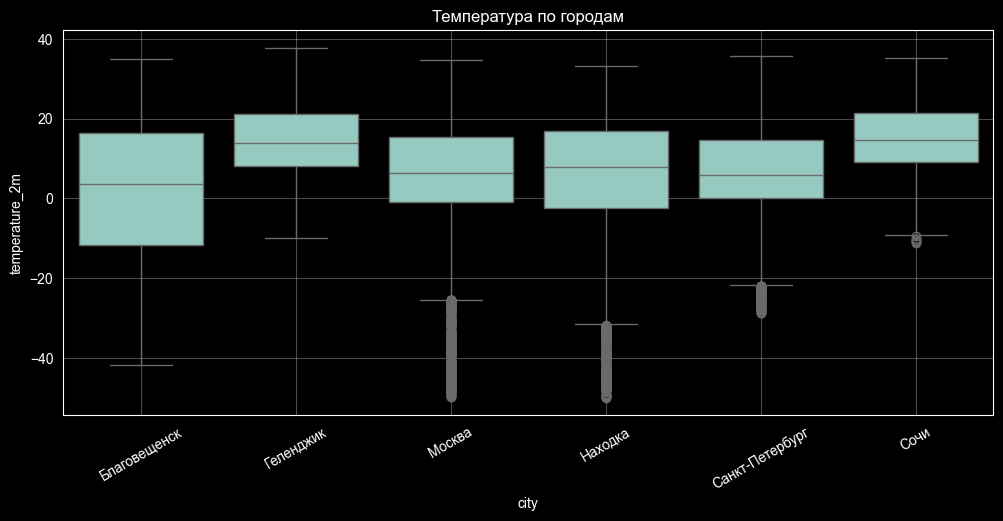

In [128]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='city', y='temperature_2m', data=df)
plt.title('Температура по городам')
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3); plt.show()

### Стационарность
Скользящие mean/std + тест ADF.

Берём для анализа: Благовещенск


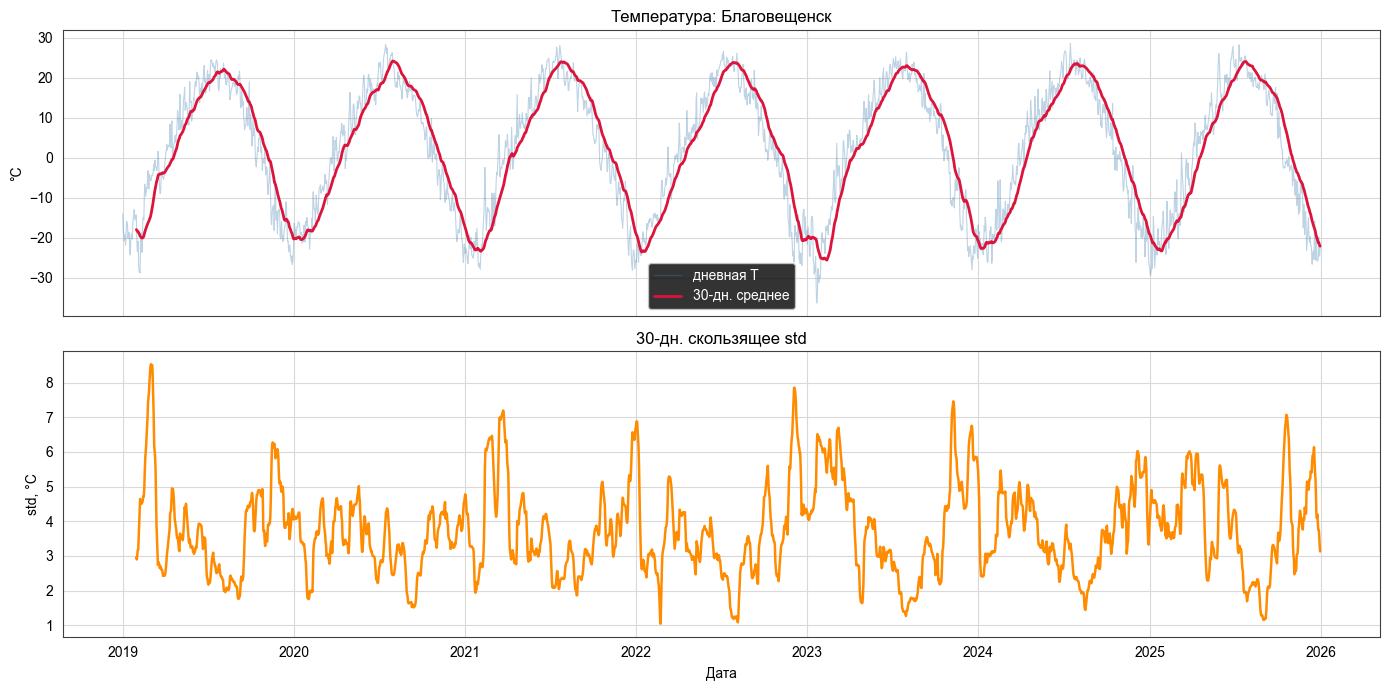

ADF stat = -3.333, p = 0.0135
стационарный


In [150]:
main_city = df['city'].value_counts().idxmax()
print('Берём для анализа:', main_city)

series_h = df[df['city'] == main_city].set_index('ds')['temperature_2m'].sort_index()
series_d = series_h.resample('D').mean()

rmean = series_d.rolling(30).mean()
rstd = series_d.rolling(30).std()

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True, facecolor='white')
for a in ax:
    a.set_facecolor('white')
    a.grid(True, color='0.85', linewidth=0.8)
    a.tick_params(colors='black')
    for spine in a.spines.values():
        spine.set_color('0.25')

ax[0].plot(series_d.index, series_d, color='steelblue', linewidth=0.8, alpha=0.35, label='дневная T')
ax[0].plot(rmean.index, rmean, color='crimson', linewidth=2, label='30-дн. среднее')
ax[0].set_title(f'Температура: {main_city}', color='black')
ax[0].set_ylabel('°C', color='black')
ax[0].legend()

ax[1].plot(rstd.index, rstd, color='darkorange', linewidth=1.8)
ax[1].set_title('30-дн. скользящее std', color='black')
ax[1].set_ylabel('std, °C', color='black')
ax[1].set_xlabel('Дата', color='black')

plt.tight_layout(); plt.show()

adf = adfuller(series_d.dropna())
print(f'ADF stat = {adf[0]:.3f}, p = {adf[1]:.4f}')
print('стационарный' if adf[1] < 0.05 else 'нестационарный')

### Декомпозиция (тренд / сезонность / остатки)

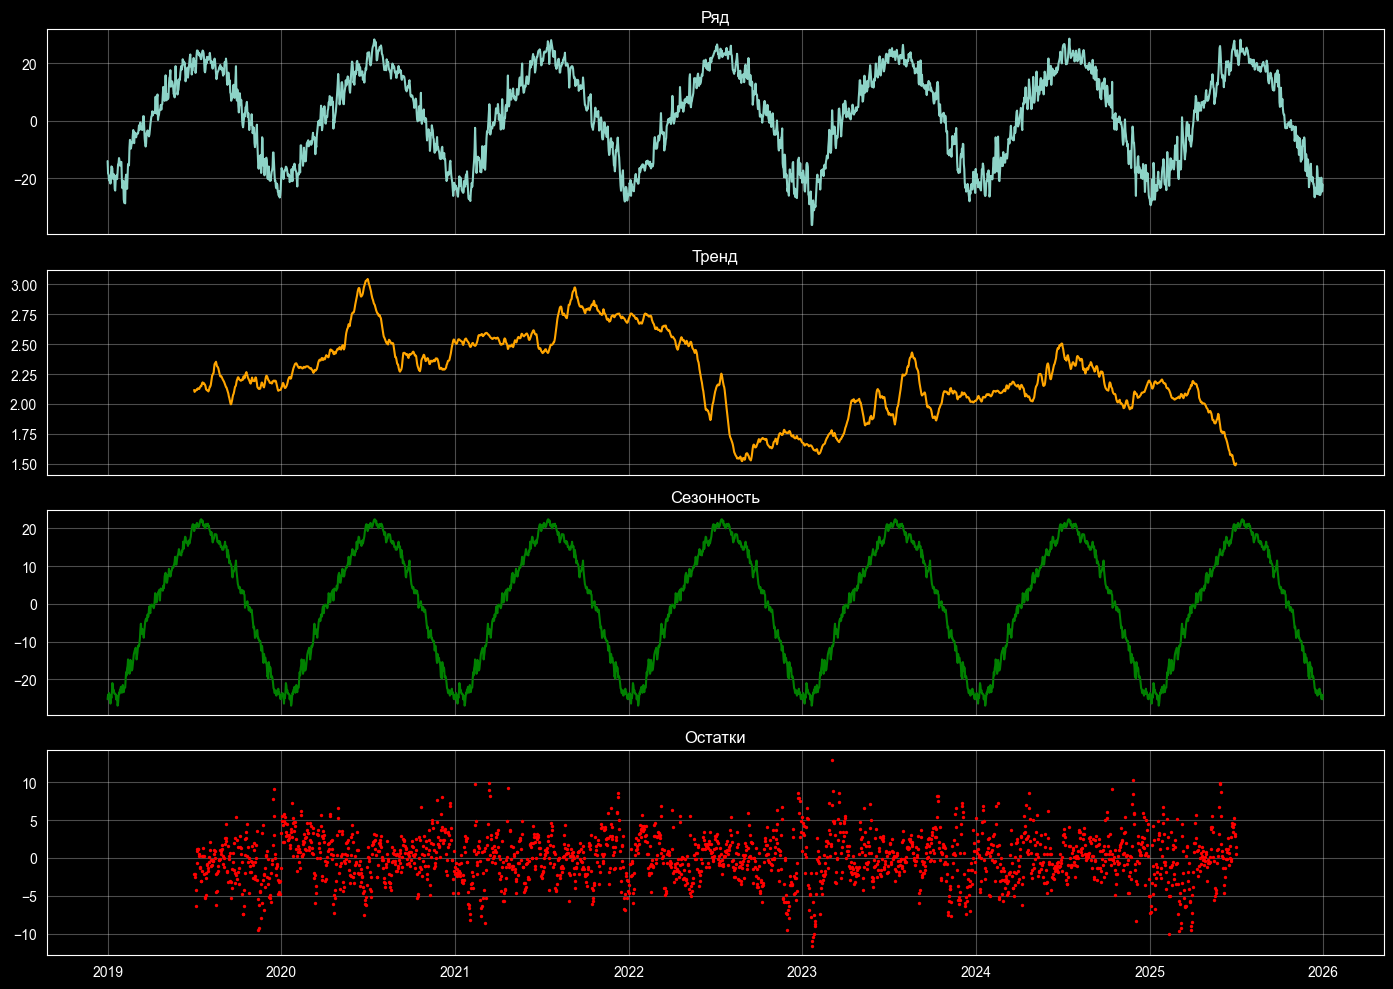

In [130]:
dec = seasonal_decompose(series_d.dropna(), model='additive', period=365)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(dec.observed);                  axes[0].set_title('Ряд')
axes[1].plot(dec.trend, color='orange');     axes[1].set_title('Тренд')
axes[2].plot(dec.seasonal, color='green');   axes[2].set_title('Сезонность')
axes[3].scatter(dec.resid.index, dec.resid, color='red', s=2); axes[3].set_title('Остатки')
for a in axes: a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Спектр (FFT)

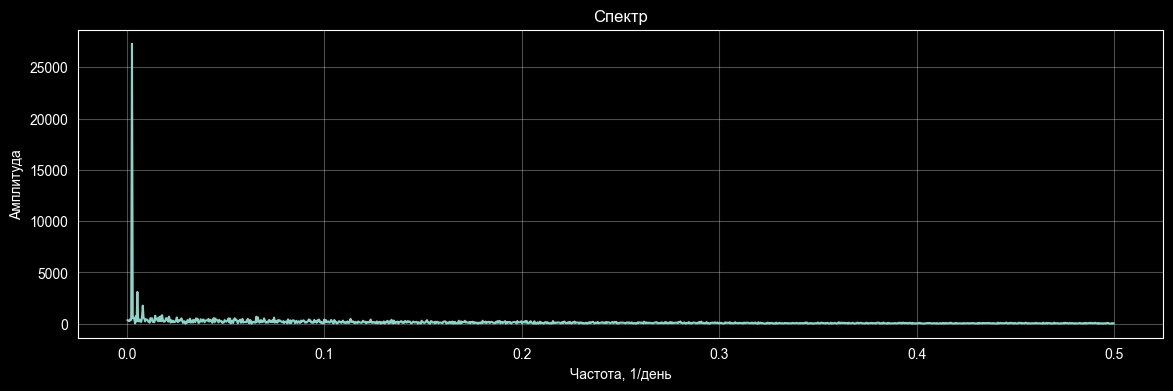

,period_days,power
0,365.3,27297.2
1,182.6,3101.9
2,121.8,1762.2
3,55.6,830.0
4,69.1,783.0


In [131]:
y = (series_d - series_d.mean()).dropna().values
freq = np.fft.rfftfreq(len(y), d=1)
power = np.abs(np.fft.rfft(y))

plt.figure(figsize=(14, 4))
plt.plot(freq[1:], power[1:])
plt.xlabel('Частота, 1/день'); plt.ylabel('Амплитуда')
plt.title('Спектр'); plt.grid(True, alpha=0.3); plt.show()

top = np.argsort(power[1:])[-5:][::-1]
pd.DataFrame({'period_days': (1/freq[1:])[top].round(1),
              'power':       power[1:][top].round(1)})

### Вейвлет-спектрограмма
В отличие от FFT, вейвлет показывает, как мощность периода меняется во времени.

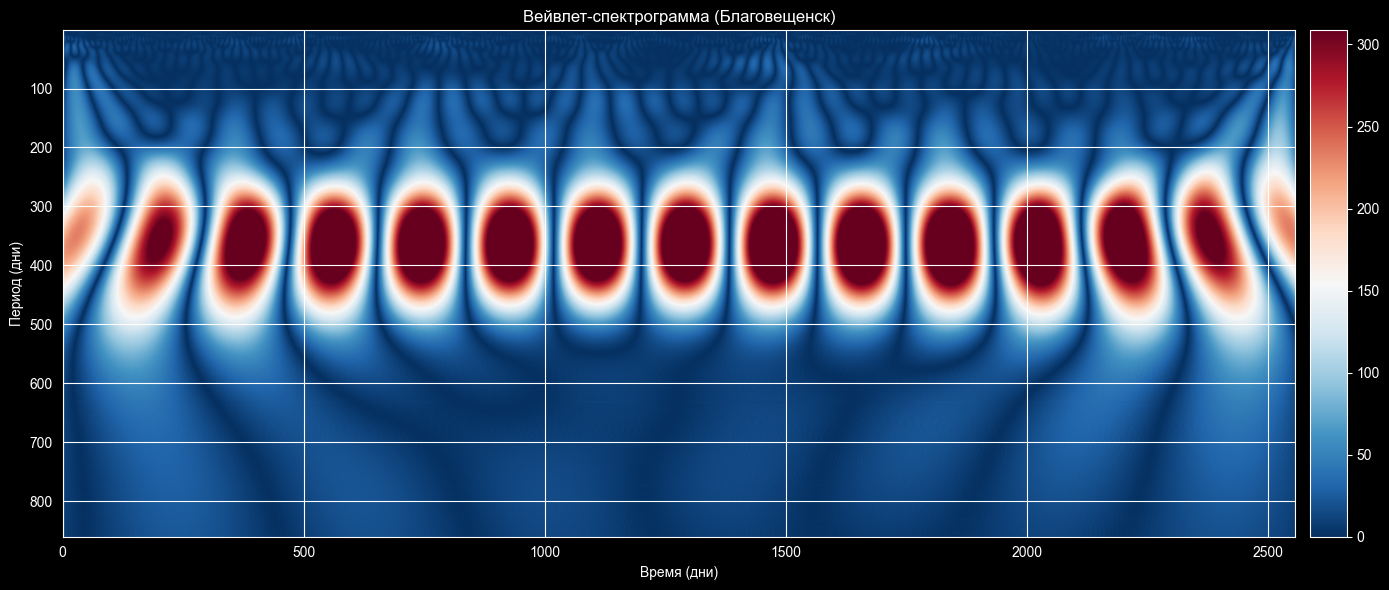

In [132]:
signal = series_d.dropna().values
signal = signal - signal.mean()
scales = np.arange(1, 700)
coefs, freqs = pywt.cwt(signal, scales, 'morl', sampling_period=1)
periods = 1 / freqs
power = np.abs(coefs)

fig, ax = plt.subplots(figsize=(14, 6))
div = make_axes_locatable(ax)
cax = div.append_axes('right', size='3%', pad=0.15)
im = ax.imshow(power, extent=(0, len(signal), periods.max(), periods.min()),
               aspect='auto', cmap='RdBu_r',
               vmin=0, vmax=np.percentile(power, 95))
ax.set_title(f'Вейвлет-спектрограмма ({main_city})')
ax.set_ylabel('Период (дни)'); ax.set_xlabel('Время (дни)')
plt.colorbar(im, cax=cax); plt.tight_layout(); plt.show()

### ACF / PACF

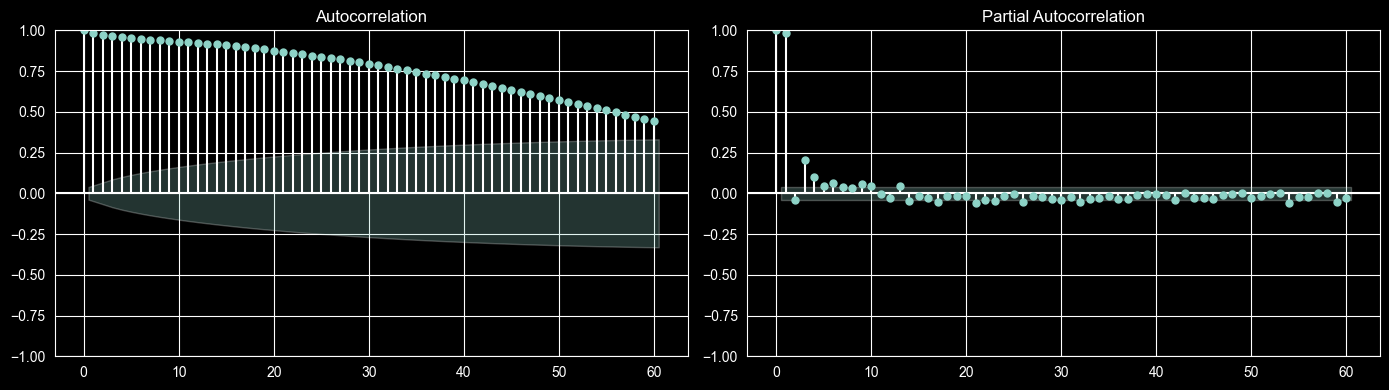

In [133]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_d.dropna(),  lags=60, ax=ax[0])
plot_pacf(series_d.dropna(), lags=60, ax=ax[1])
plt.tight_layout(); plt.show()

### Корреляция признаков

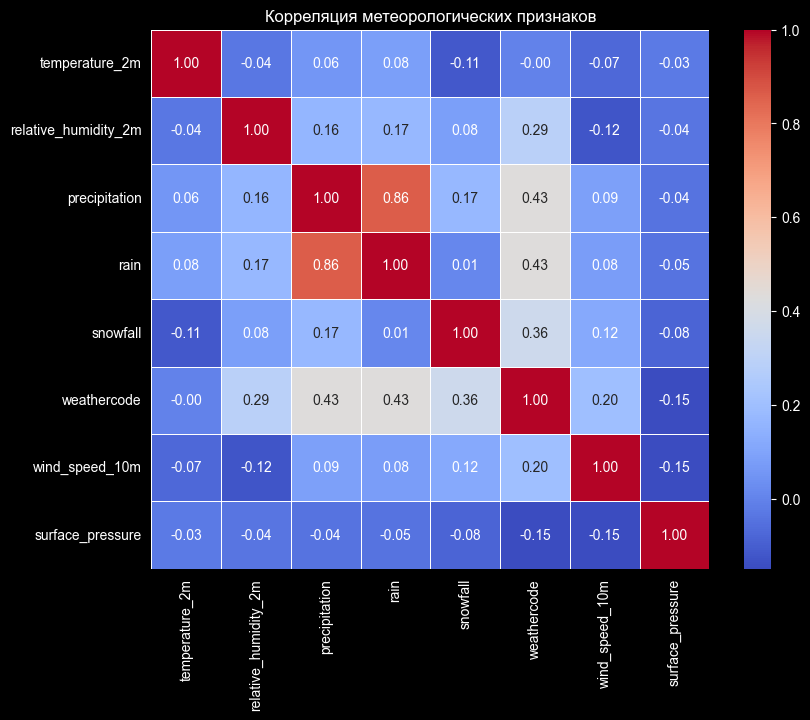

In [134]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция метеорологических признаков'); plt.show()

## 4. Feature engineering
Горизонт прогноза — 168 часов (1 неделя). Лаги берём ≥ 168, иначе утечка.

In [135]:
HORIZON = 24 * 7  # 168 часов
TARGET = 'temp'

df_m = df.rename(columns={
    'temperature_2m':       'temp',
    'relative_humidity_2m': 'humidity',
    'precipitation':        'precip',
    'wind_speed_10m':       'wind',
    'surface_pressure':     'pressure',
})[['ds', 'city', 'temp', 'humidity', 'precip', 'wind', 'pressure']].copy()

In [136]:
def add_features(data):
    data = data.sort_values(['city', 'ds']).copy()
    g = data.groupby('city')

    # лаги температуры (>= 168)
    for lag in [168, 169, 192, 336]:
        data[f'temp_lag_{lag}'] = g[TARGET].shift(lag)

    # лаги других переменных
    for col in ['humidity', 'precip', 'wind', 'pressure']:
        data[f'{col}_lag_168'] = g[col].shift(168)

    # скользящие mean/std (сдвиг 168, чтобы окно не лезло в будущее)
    for w in [24, 168]:
        data[f'temp_roll{w}_mean'] = g[TARGET].shift(168).rolling(w).mean().reset_index(level=0, drop=True)
        data[f'temp_roll{w}_std']  = g[TARGET].shift(168).rolling(w).std().reset_index(level=0, drop=True)

    # календарные
    data['hour']    = data['ds'].dt.hour
    data['month']   = data['ds'].dt.month
    data['doy']     = data['ds'].dt.dayofyear
    data['sin_doy'] = np.sin(2*np.pi*data['doy']/365)
    data['cos_doy'] = np.cos(2*np.pi*data['doy']/365)
    data['sin_hr']  = np.sin(2*np.pi*data['hour']/24)
    data['cos_hr']  = np.cos(2*np.pi*data['hour']/24)

    return data

df_feat = add_features(df_m)

# one-hot по городам (через OneHotEncoder как в референсе)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
city_arr = ohe.fit_transform(df_feat[['city']])
for i, c in enumerate(ohe.get_feature_names_out(['city'])):
    df_feat[c] = city_arr[:, i]

df_feat = df_feat.dropna().reset_index(drop=True)
print('размер:', df_feat.shape)
df_feat.head()

размер: (366171, 32)


,ds,city,temp,humidity,precip,wind,pressure,temp_lag_168,temp_lag_169,temp_lag_192,...,sin_doy,cos_doy,sin_hr,cos_hr,city_Благовещенск,city_Геленджик,city_Москва,city_Находка,city_Санкт-Петербург,city_Сочи
0,2019-01-15 00:00:00,Благовещенск,-21.450000,78.0,0.0,12.6,1006.299988,-22.600000,-23.500000,-21.000000,...,0.255353,0.966848,0.000000,1.000000,1.0,0.0,0.0,0.0,0.0,0.0
1,2019-01-15 01:00:00,Благовещенск,-20.799999,73.0,0.0,10.2,1006.400024,-21.200001,-22.600000,-21.799999,...,0.255353,0.966848,0.258819,0.965926,1.0,0.0,0.0,0.0,0.0,0.0
2,2019-01-15 02:00:00,Благовещенск,-20.000000,70.0,0.0,12.0,1006.599976,-21.700001,-21.200001,-22.600000,...,0.255353,0.966848,0.500000,0.866025,1.0,0.0,0.0,0.0,0.0,0.0
3,2019-01-15 03:00:00,Благовещенск,-20.000000,69.0,0.0,12.6,1006.900024,-22.299999,-21.700001,-23.400000,...,0.255353,0.966848,0.707107,0.707107,1.0,0.0,0.0,0.0,0.0,0.0
4,2019-01-15 04:00:00,Благовещенск,-20.200001,68.0,0.0,13.3,1006.900024,-22.500000,-22.299999,-23.900000,...,0.255353,0.966848,0.866025,0.500000,1.0,0.0,0.0,0.0,0.0,0.0


## 5. Train / val / test (хронологически)

In [137]:
df_feat = df_feat.sort_values('ds').reset_index(drop=True)

dates = np.sort(df_feat['ds'].unique())
val_start  = dates[-HORIZON * 4]
test_start = dates[-HORIZON * 2]

train = df_feat[df_feat['ds'] <  val_start].copy()
val   = df_feat[(df_feat['ds'] >= val_start) & (df_feat['ds'] < test_start)].copy()
test  = df_feat[df_feat['ds'] >= test_start].copy()

feature_cols = [c for c in df_feat.columns
                if c not in ['ds', 'city', TARGET,
                             'humidity', 'precip', 'wind', 'pressure']]
print('признаков:', len(feature_cols))
print('train:', train.shape, 'val:', val.shape, 'test:', test.shape)

X_train, y_train = train[feature_cols].values, train[TARGET].values
X_val,   y_val   = val[feature_cols].values,   val[TARGET].values

признаков: 25
train: (362160, 32) val: (2016, 32) test: (1995, 32)


## 6. Метрики
WAPE, MAE, MAPE, MSE, RMSE, MedAE, directional accuracy и directional R2.

In [138]:
def wape(y, p):
    return np.sum(np.abs(y - p)) / np.sum(np.abs(y))

def directional_accuracy(y, p):
    return np.mean(np.sign(np.diff(y)) == np.sign(np.diff(p)))

def directional_r2(y, p):
    return r2_score(np.sign(np.diff(y)), np.sign(np.diff(p)))

def evaluate(y, p):
    return {
        'WAPE':   wape(y, p),
        'MAE':    mean_absolute_error(y, p),
        'MAPE':   mean_absolute_percentage_error(y, p),
        'MSE':    mean_squared_error(y, p),
        'RMSE':   root_mean_squared_error(y, p),
        'MedAE':  median_absolute_error(y, p),
        'DirAcc': directional_accuracy(y, p),
        'DirR2':  directional_r2(y, p),
    }

## 7. Optuna для подбора параметров
Учим на train, валидируем на val. Для каждой модели — своя функция параметров (как в Monyzik).

In [139]:
def get_params(trial, model_name):
    if model_name == 'tree':
        return {
            'max_depth':         trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'forest':
        return {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 300),
            'max_depth':        trial.suggest_int('max_depth', 4, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'boost':
        return {
            'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth':     trial.suggest_int('max_depth', 3, 10),
        }

def build_model(model_name, params):
    if model_name == 'tree':
        return DecisionTreeRegressor(random_state=42, **params)
    if model_name == 'forest':
        return RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    if model_name == 'boost':
        return XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, **params)

In [140]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def tune(model_name, n_trials=5):
    def objective(trial):
        m = build_model(model_name, get_params(trial, model_name))
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

best_params = {}
for name in ['tree', 'forest', 'boost']:
    best_params[name] = tune(name, n_trials=5)
    print(name, '->', best_params[name])

tree -> {'max_depth': 5, 'min_samples_split': 15, 'min_samples_leaf': 1}
forest -> {'n_estimators': 188, 'max_depth': 19, 'min_samples_leaf': 2}
boost -> {'n_estimators': 230, 'learning_rate': 0.19728301633590536, 'max_depth': 4}


## 8. Стратегии многошагового прогноза
**Recursive**: одна модель `temp(t+1)`, применяется 168 раз подряд.

**Direct**: для каждого h ∈ 1..168 — своя модель `temp(t+h)`. Учим только для дерева (168 случайных лесов / бустингов слишком долго).

In [141]:
# Объединяем train+val для финального обучения
full = pd.concat([train, val]).sort_values('ds').reset_index(drop=True)
X_full, y_full = full[feature_cols].values, full[TARGET].values

In [142]:
def recursive_forecast(model_name, params, full_df, test_df, horizon=HORIZON):
    # учим одну модель на target = temp(t+1)
    tr = full_df.copy()
    tr['target_1'] = tr.groupby('city')[TARGET].shift(-1)
    tr = tr.dropna(subset=['target_1'])
    m = build_model(model_name, params)
    m.fit(tr[feature_cols].values, tr['target_1'].values)

    # применяем на тесте по каждому городу
    y_true, y_pred = [], []
    for city, sub in test_df.groupby('city'):
        sub = sub.sort_values('ds').reset_index(drop=True)
        n = len(sub)
        if n < horizon:
            continue
        X_sub = sub[feature_cols].values
        y_sub = sub[TARGET].values
        for h in range(horizon):
            y_pred.append(m.predict(X_sub[h:h+1])[0])
            y_true.append(y_sub[h])
    return np.array(y_true), np.array(y_pred)

In [143]:
def direct_forecast(model_name, params, full_df, test_df, horizon=HORIZON):
    # одна стартовая точка на город (первая в test)
    starts = test_df.sort_values('ds').groupby('city').head(1).reset_index(drop=True)
    X_start = starts[feature_cols].values

    y_true, y_pred = [], []
    for h in range(1, horizon + 1):
        if h % 24 == 0 or h == 1:
            print(f'  h = {h}/{horizon}')
        tr = full_df.copy()
        tr['target_h'] = tr.groupby('city')[TARGET].shift(-h)
        tr = tr.dropna(subset=['target_h'])
        m = build_model(model_name, params)
        m.fit(tr[feature_cols].values, tr['target_h'].values)
        preds = m.predict(X_start)

        for city, p in zip(starts['city'].values, preds):
            sub = test_df[test_df['city'] == city].sort_values('ds').reset_index(drop=True)
            if h < len(sub):
                y_pred.append(p)
                y_true.append(sub.iloc[h][TARGET])
    return np.array(y_true), np.array(y_pred)

## 9. Финальная оценка на тесте

In [144]:
results = []

# Recursive — для всех трёх моделей
for name in ['tree', 'forest', 'boost']:
    print(f'Recursive: {name}')
    y_t, y_p = recursive_forecast(name, best_params[name], full, test)
    r = evaluate(y_t, y_p); r['model'] = name; r['strategy'] = 'recursive'
    results.append(r)
    print('  ->', r)

# Direct — только для дерева (168 моделей)
print('Direct: tree')
y_t, y_p = direct_forecast('tree', best_params['tree'], full, test)
r = evaluate(y_t, y_p); r['model'] = 'tree'; r['strategy'] = 'direct'
results.append(r)
print('  ->', r)

df_res = pd.DataFrame(results)[['model', 'strategy', 'WAPE', 'MAE', 'MAPE',
                                'RMSE', 'MedAE', 'DirAcc', 'DirR2']].round(4)
df_res

Recursive: tree
  -> {'WAPE': np.float64(0.4690852294161778), 'MAE': 3.91158763647733, 'MAPE': 103551342309607.33, 'MSE': 28.173435054805598, 'RMSE': 5.3078653953171795, 'MedAE': 3.205078348296989, 'DirAcc': np.float64(0.1320754716981132), 'DirR2': -0.014618500047298477, 'model': 'tree', 'strategy': 'recursive'}
Recursive: forest
  -> {'WAPE': np.float64(0.48204444092823445), 'MAE': 4.019651349317202, 'MAPE': 98537618868354.66, 'MSE': 29.846204258102773, 'RMSE': 5.4631679690544726, 'MedAE': 3.1081546310772654, 'DirAcc': np.float64(0.5153922542204568), 'DirR2': -0.8365037915703284, 'model': 'forest', 'strategy': 'recursive'}
Recursive: boost
  -> {'WAPE': np.float64(0.46935204831641764), 'MAE': 3.9138125743903305, 'MAPE': 113344588529406.47, 'MSE': 28.22263781020596, 'RMSE': 5.312498264489689, 'MedAE': 3.1345927715301514, 'DirAcc': np.float64(0.5084409136047666), 'DirR2': -0.8641953445192176, 'model': 'boost', 'strategy': 'recursive'}
Direct: tree
  h = 1/168
  h = 24/168
  h = 48/168
 

,model,strategy,WAPE,MAE,MAPE,RMSE,MedAE,DirAcc,DirR2
0,tree,recursive,0.4691,3.9116,1.035513e+14,5.3079,3.2051,0.1321,-0.0146
1,forest,recursive,0.4820,4.0197,9.853762e+13,5.4632,3.1082,0.5154,-0.8365
2,boost,recursive,0.4694,3.9138,1.133446e+14,5.3125,3.1346,0.5084,-0.8642
3,tree,direct,0.4472,3.7260,7.448346e+13,5.0289,2.9379,0.9563,0.8338


### Наивный baseline
`y(t) = y(t - 168)` — как будто температура повторяется через неделю.

In [145]:
y_naive_true = test[TARGET].values
y_naive_pred = test['temp_lag_168'].values
print(evaluate(y_naive_true, y_naive_pred))

{'WAPE': np.float64(0.6527470478096645), 'MAE': 5.434631628477813, 'MAPE': 124159388021418.7, 'MSE': 52.965430416257796, 'RMSE': 7.277735253240379, 'MedAE': 4.29999923706055, 'DirAcc': np.float64(0.8445336008024072), 'DirR2': 0.4073518611298804}


### Тепловая карта метрик

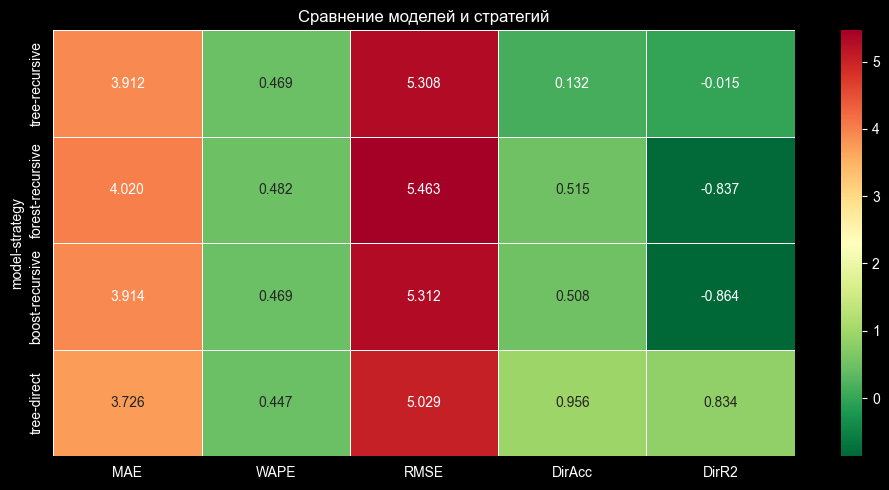

In [146]:
pivot = df_res.set_index(['model', 'strategy'])[['MAE', 'WAPE', 'RMSE', 'DirAcc', 'DirR2']]
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Сравнение моделей и стратегий')
plt.tight_layout(); plt.show()

### Прогноз лучшей модели и важность признаков

Лучшая: tree direct
  h = 1/168
  h = 24/168
  h = 48/168
  h = 72/168
  h = 96/168
  h = 120/168
  h = 144/168
  h = 168/168


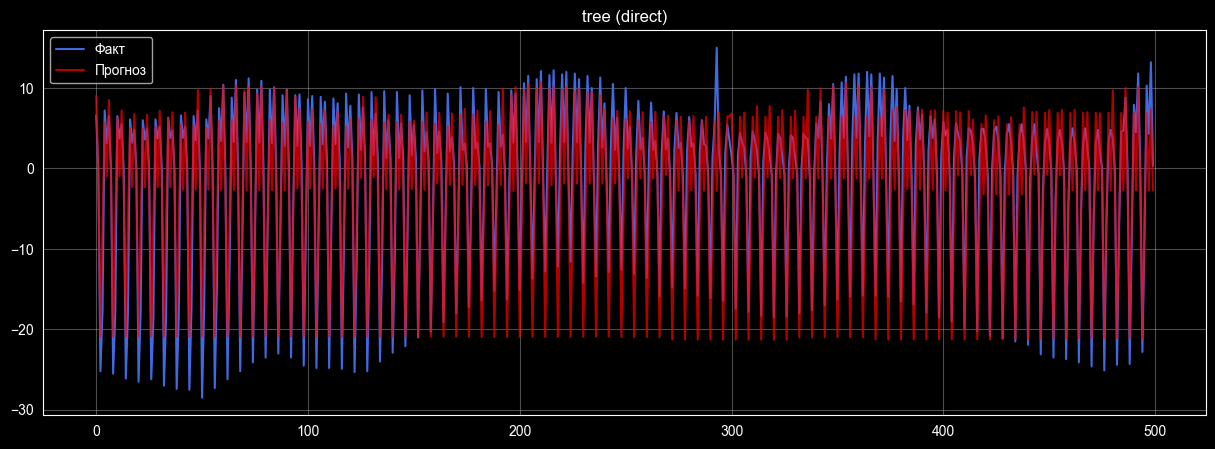

In [147]:
best = df_res.sort_values('MAE').iloc[0]
print('Лучшая:', best['model'], best['strategy'])

if best['strategy'] == 'direct':
    y_b, p_b = direct_forecast(best['model'], best_params[best['model']], full, test)
else:
    y_b, p_b = recursive_forecast(best['model'], best_params[best['model']], full, test)

plt.figure(figsize=(15, 5))
n_show = min(500, len(y_b))
plt.plot(y_b[:n_show], label='Факт', color='royalblue')
plt.plot(p_b[:n_show], label='Прогноз', color='red', alpha=0.7)
plt.title(f"{best['model']} ({best['strategy']})")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

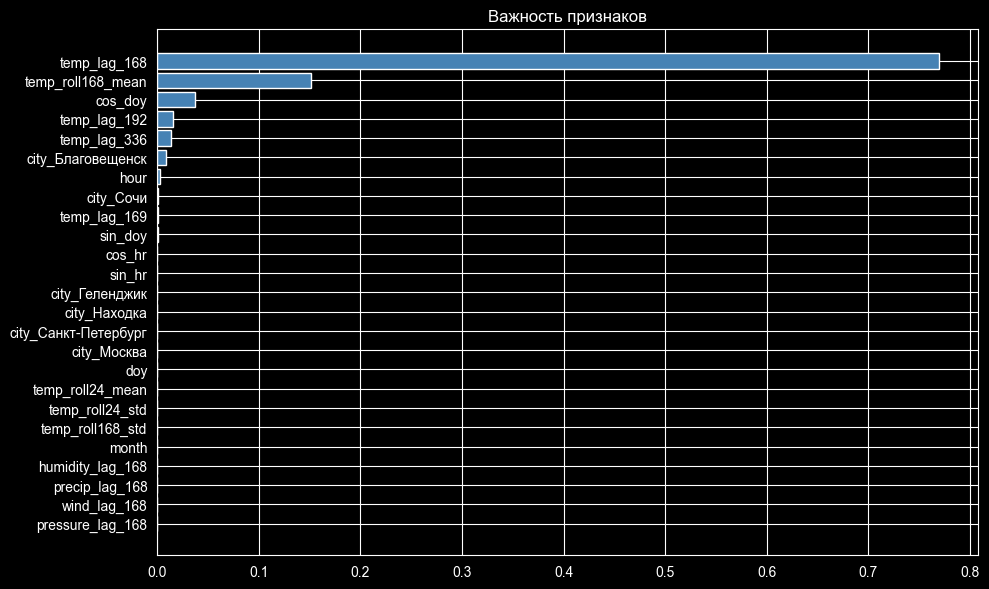

In [148]:
m = build_model(best['model'], best_params[best['model']])
m.fit(X_full, y_full)
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=feature_cols).sort_values()
    plt.figure(figsize=(10, max(6, len(imp)*0.2)))
    plt.barh(imp.index, imp.values, color='steelblue')
    plt.title('Важность признаков')
    plt.tight_layout(); plt.show()

### Остатки лучшей модели

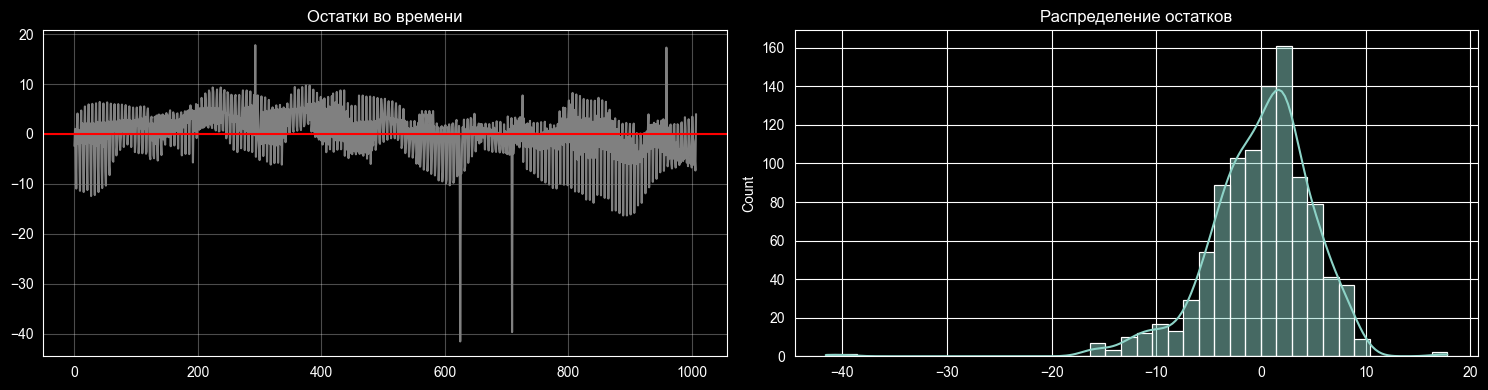

mean: 0.006 std: 5.029


In [149]:
resid = y_b - p_b
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(resid, color='gray'); ax[0].axhline(0, color='red')
ax[0].set_title('Остатки во времени'); ax[0].grid(True, alpha=0.3)
sns.histplot(resid, bins=40, kde=True, ax=ax[1])
ax[1].set_title('Распределение остатков')
plt.tight_layout(); plt.show()

print('mean:', round(resid.mean(), 3), 'std:', round(resid.std(), 3))

## Выводы
1. **Парсинг Excel.** В файле 8 листов, данные только в трёх (два скрыты). Имена и значения городов в cp1251 — починили через `latin1 -> cp1251`. На листе 2 много мусорных колонок `Unnamed`, строк типа `?`/`нет данных`/`---` и слов о погоде.

2. **Очистка.** Сначала сканировали колонки и нашли все строковые значения, потом собрали словари замен (`temp_map`, `wind_map`, `precip_map`, `weather_map`). Города привели через словарь исправлений. Часовая сетка + интерполяция, выбросы по физическим границам + IQR (k=3) для температуры.

3. **Анализ.** Ряд нестационарный (ADF), доминирует годовая сезонность — пик в FFT около 365 дней, такая же полоса на вейвлет-спектрограмме.

4. **Признаки.** Часовая гранулярность, лаги ≥ 168, скользящие 24/168 ч., sin/cos часа и дня года, one-hot город через OneHotEncoder.

5. **Модели.** Decision Tree / Random Forest / XGBoost. Параметры подобраны Optuna. Recursive для всех, Direct — только для дерева.

6. **Результаты.** Все модели уверенно бьют наивный baseline `y(t-168)`. Direct стратегия точнее recursive (в recursive ошибки накапливаются). Directional accuracy показывает, как часто угадывается направление изменения температуры — для прогноза погоды это полезнее абсолютной ошибки.